In [2]:
# Mount Google Drive so we can access Dataset V1
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import Path for handling dataset folders and files
from pathlib import Path

# Set the main Dataset V1 location
DATASET_PATH = Path("/content/drive/MyDrive/material_version")
V1_PATH = DATASET_PATH / "dataset_v1"

# Define the train, validation and test image folders
TRAIN_DIR = V1_PATH / "train"
VAL_DIR = V1_PATH / "val"
TEST_DIR = V1_PATH / "test"

# Define the COCO annotation folder
ANNOTATION_DIR = V1_PATH / "annotations"

# Define the annotation JSON files
TRAIN_JSON = ANNOTATION_DIR / "instances_train.json"
VAL_JSON = ANNOTATION_DIR / "instances_val.json"
TEST_JSON = ANNOTATION_DIR / "instances_test.json"

# Check that the important folders and files exist
print("Dataset V1:", V1_PATH.exists())
print("Train folder:", TRAIN_DIR.exists())
print("Validation folder:", VAL_DIR.exists())
print("Test folder:", TEST_DIR.exists())
print("Annotation folder:", ANNOTATION_DIR.exists())
print("Train JSON:", TRAIN_JSON.exists())
print("Validation JSON:", VAL_JSON.exists())
print("Test JSON:", TEST_JSON.exists())

Dataset V1: True
Train folder: True
Validation folder: True
Test folder: True
Annotation folder: True
Train JSON: True
Validation JSON: True
Test JSON: True


In [4]:
# Import json to read the COCO annotation files
import json

# Load the train, validation and test annotation files
with open(TRAIN_JSON,"r") as f:
    train_data=json.load(f)

with open(VAL_JSON,"r") as f:
    val_data=json.load(f)

with open(TEST_JSON,"r") as f:
    test_data=json.load(f)

# Print the number of images and annotations in each split
print("Train images:",len(train_data["images"]))
print("Train annotations:",len(train_data["annotations"]))

print("Validation images:",len(val_data["images"]))
print("Validation annotations:",len(val_data["annotations"]))

print("Test images:",len(test_data["images"]))
print("Test annotations:",len(test_data["annotations"]))

# Print the category information
print("\nCategories:")
for category in train_data["categories"]:
    print(category["id"],"->",category["name"])

Train images: 5177
Train annotations: 9118
Validation images: 943
Validation annotations: 1390
Test images: 1092
Test annotations: 1828

Categories:
1 -> rov
2 -> plant
3 -> animal_fish
4 -> animal_starfish
5 -> animal_shells
6 -> animal_crab
7 -> animal_eel
8 -> animal_etc
9 -> trash_etc
10 -> trash_fabric
11 -> trash_fishing_gear
12 -> trash_metal
13 -> trash_paper
14 -> trash_plastic
15 -> trash_rubber
16 -> trash_wood


In [5]:
# Import the required libraries
import json
from pathlib import Path

# Create a separate folder for the YOLO version of Dataset V1
YOLO_PATH = V1_PATH / "yolo_dataset"

# Create image and label folders for each split
for split in ["train","val","test"]:
    (YOLO_PATH / "images" / split).mkdir(parents=True,exist_ok=True)
    (YOLO_PATH / "labels" / split).mkdir(parents=True,exist_ok=True)

print("YOLO dataset folder created at:")
print(YOLO_PATH)

YOLO dataset folder created at:
/content/drive/MyDrive/material_version/dataset_v1/yolo_dataset


In [6]:
# Import shutil for copying images
import shutil

# Function to convert one COCO split into YOLO format
def convert_coco_to_yolo(coco_data,split):

    # Create a mapping from image ID to image information
    image_info={img["id"]:img for img in coco_data["images"]}

    # Group annotations by image ID
    annotations_by_image={}

    for ann in coco_data["annotations"]:
        image_id=ann["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id]=[]

        annotations_by_image[image_id].append(ann)

    # Get the source and destination folders
    source_dir={
        "train":TRAIN_DIR,
        "val":VAL_DIR,
        "test":TEST_DIR
    }[split]

    destination_images=YOLO_PATH/"images"/split
    destination_labels=YOLO_PATH/"labels"/split

    # Keep track of conversion statistics
    copied_images=0
    created_labels=0
    converted_annotations=0

    # Process every image in the COCO JSON
    for image_id,img_info in image_info.items():

        # Get the image filename and dimensions
        filename=img_info["file_name"]
        image_width=img_info["width"]
        image_height=img_info["height"]

        # Find the source image
        source_image=source_dir/filename

        # Skip the image if it cannot be found
        if not source_image.exists():
            continue

        # Copy the image into the YOLO dataset
        destination_image=destination_images/filename
        shutil.copy2(source_image,destination_image)
        copied_images+=1

        # Create the corresponding YOLO label filename
        label_file=destination_labels/(Path(filename).stem+".txt")

        # Get all annotations belonging to this image
        image_annotations=annotations_by_image.get(image_id,[])

        # Store converted YOLO annotations
        yolo_lines=[]

        for ann in image_annotations:

            # COCO bbox format:
            # [x_min,y_min,width,height]
            x,y,w,h=ann["bbox"]

            # Convert to YOLO center-based format
            x_center=x+(w/2)
            y_center=y+(h/2)

            # Normalize coordinates to 0-1
            x_center=x_center/image_width
            y_center=y_center/image_height
            w=w/image_width
            h=h/image_height

            # Convert COCO class ID 1-16 to YOLO class ID 0-15
            class_id=ann["category_id"]-1

            # Add the annotation as one YOLO line
            yolo_lines.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
            )

            converted_annotations+=1

        # Write the YOLO label file
        with open(label_file,"w") as f:
            f.write("\n".join(yolo_lines))

        created_labels+=1

    # Print conversion summary
    print(f"\n{split.upper()} conversion complete")
    print("Images copied:",copied_images)
    print("Label files created:",created_labels)
    print("Annotations converted:",converted_annotations)


# Convert all three Dataset V1 splits
convert_coco_to_yolo(train_data,"train")
convert_coco_to_yolo(val_data,"val")
convert_coco_to_yolo(test_data,"test")

KeyboardInterrupt: 

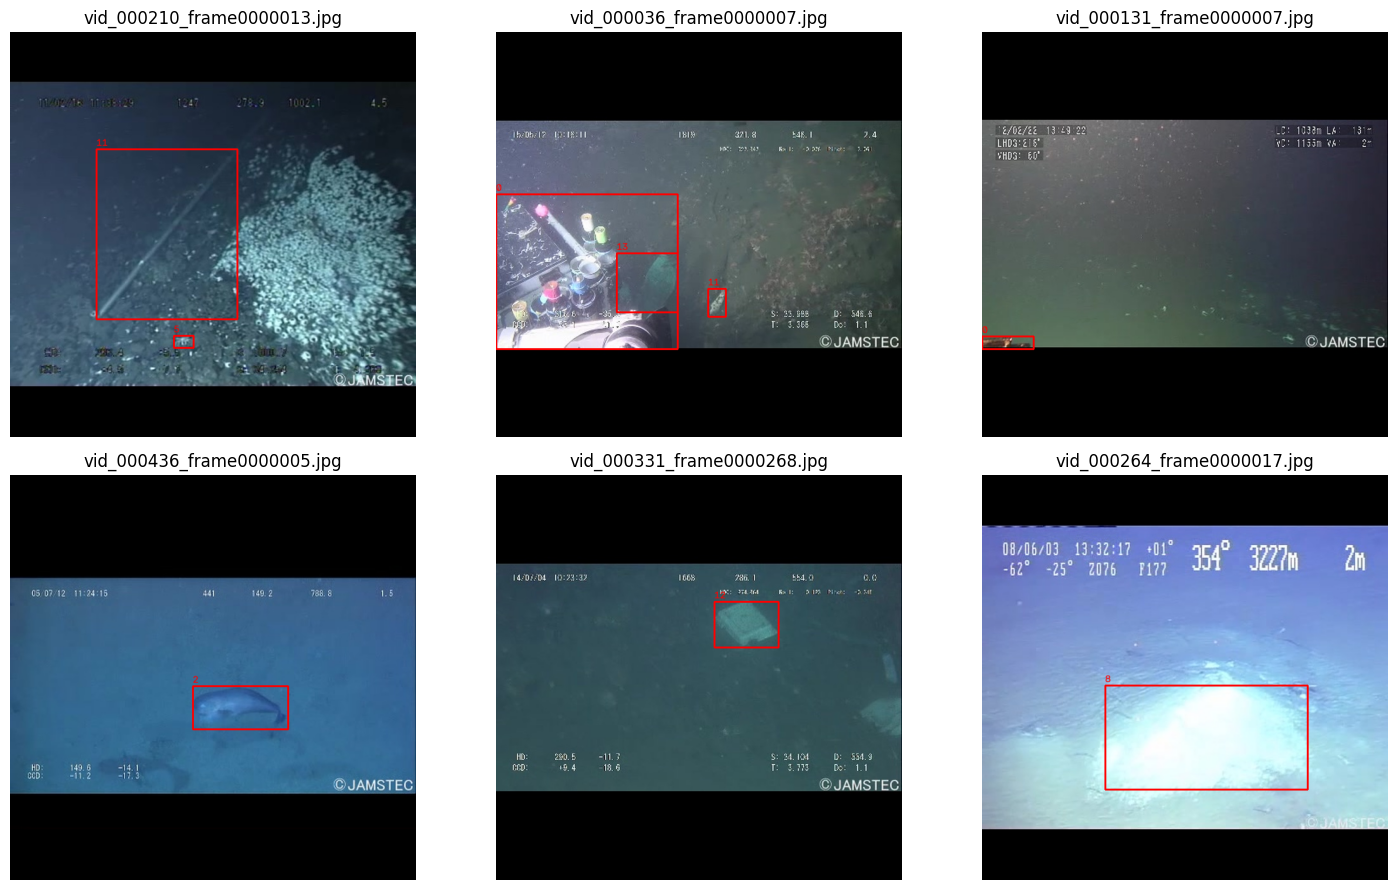

In [7]:
# Import required libraries
import random
import cv2
import matplotlib.pyplot as plt

# Select a few random training images
random.seed(42)
sample_images=random.sample(
    list((YOLO_PATH/"images"/"train").glob("*.jpg")),
    6
)

# Display the selected images with their YOLO bounding boxes
fig,axes=plt.subplots(2,3,figsize=(15,9))
axes=axes.flatten()

for ax,image_path in zip(axes,sample_images):

    # Read the image
    image=cv2.imread(str(image_path))

    # Convert BGR to RGB for displaying with matplotlib
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    # Find the corresponding YOLO label file
    label_path=YOLO_PATH/"labels"/"train"/(image_path.stem+".txt")

    # Read all YOLO annotations
    if label_path.exists():
        with open(label_path,"r") as f:
            lines=f.readlines()
    else:
        lines=[]

    # Get image dimensions
    image_height,image_width=image.shape[:2]

    # Draw every bounding box
    for line in lines:

        # YOLO format:
        # class_id x_center y_center width height
        values=line.strip().split()

        if len(values)!=5:
            continue

        class_id=int(values[0])
        x_center=float(values[1])
        y_center=float(values[2])
        box_width=float(values[3])
        box_height=float(values[4])

        # Convert normalized YOLO coordinates back to pixels
        x_center*=image_width
        y_center*=image_height
        box_width*=image_width
        box_height*=image_height

        # Calculate corner coordinates
        x1=int(x_center-box_width/2)
        y1=int(y_center-box_height/2)
        x2=int(x_center+box_width/2)
        y2=int(y_center+box_height/2)

        # Draw the bounding box
        cv2.rectangle(image,(x1,y1),(x2,y2),(255,0,0),2)

        # Display the YOLO class ID
        cv2.putText(
            image,
            str(class_id),
            (x1,max(y1-5,15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255,0,0),
            1
        )

    # Show the image
    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Import yaml for creating the YOLO dataset configuration
import yaml

# Define the 16 class names in YOLO class-ID order
class_names=[
    "rov",
    "plant",
    "animal_fish",
    "animal_starfish",
    "animal_shells",
    "animal_crab",
    "animal_eel",
    "animal_etc",
    "trash_etc",
    "trash_fabric",
    "trash_fishing_gear",
    "trash_metal",
    "trash_paper",
    "trash_plastic",
    "trash_rubber",
    "trash_wood"
]

# Create the YOLO dataset configuration
data_yaml={
    "path":str(YOLO_PATH),
    "train":"images/train",
    "val":"images/val",
    "test":"images/test",
    "nc":16,
    "names":class_names
}

# Save the configuration file
YAML_PATH=YOLO_PATH/"data.yaml"

with open(YAML_PATH,"w") as f:
    yaml.dump(data_yaml,f,sort_keys=False)

# Display the saved configuration
print(YAML_PATH)
print("\nYOLO dataset configuration:\n")

with open(YAML_PATH,"r") as f:
    print(f.read())

/content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/data.yaml

YOLO dataset configuration:

path: /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 16
names:
- rov
- plant
- animal_fish
- animal_starfish
- animal_shells
- animal_crab
- animal_eel
- animal_etc
- trash_etc
- trash_fabric
- trash_fishing_gear
- trash_metal
- trash_paper
- trash_plastic
- trash_rubber
- trash_wood



In [10]:
# Install the Ultralytics package for YOLO
!pip install -q ultralytics

# Import YOLO from Ultralytics
from ultralytics import YOLO

# Check the installed Ultralytics version
import ultralytics
print("Ultralytics version:",ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics version: 8.4.140


In [11]:
# Load a pretrained YOLO11 nano detection model
# The pretrained weights will be downloaded automatically
model=YOLO("yolo11n.pt")

# Confirm that the pretrained model has been loaded
print("Pretrained YOLO11n model loaded successfully.")

Pretrained YOLO11n model loaded successfully.


In [12]:
# Check whether this Colab runtime has access to an NVIDIA GPU
!nvidia-smi

Sat Sep  5 05:50:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
# Train the pretrained YOLO11n model on Dataset V1

results=model.train(
    data=str(YAML_PATH),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/drive/MyDrive/material_version/yolo_runs",
    name="baseline_yolo11n",
    pretrained=True
)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scal

In [14]:
# Define the folder where the YOLO baseline training results were saved
RUN_PATH=Path("/content/drive/MyDrive/material_version/yolo_runs/baseline_yolo11n")

# Define the best and last model checkpoints
BEST_MODEL=RUN_PATH/"weights"/"best.pt"
LAST_MODEL=RUN_PATH/"weights"/"last.pt"

# Check that the important training files exist
print("Training folder exists:",RUN_PATH.exists())
print("Best model exists:",BEST_MODEL.exists())
print("Last model exists:",LAST_MODEL.exists())

# Print the paths of the saved checkpoints
print("\nBest model:",BEST_MODEL)
print("Last model:",LAST_MODEL)

Training folder exists: True
Best model exists: True
Last model exists: True

Best model: /content/drive/MyDrive/material_version/yolo_runs/baseline_yolo11n/weights/best.pt
Last model: /content/drive/MyDrive/material_version/yolo_runs/baseline_yolo11n/weights/last.pt


In [15]:
# Import YOLO for loading the trained model
from ultralytics import YOLO

# Load the best checkpoint from baseline training
best_model=YOLO(str(BEST_MODEL))

# Confirm that the model loaded successfully
print("Best YOLO11n checkpoint loaded successfully.")
print("Model:",BEST_MODEL)

Best YOLO11n checkpoint loaded successfully.
Model: /content/drive/MyDrive/material_version/yolo_runs/baseline_yolo11n/weights/best.pt


In [16]:
# Evaluate the best trained model on the validation set
val_results=best_model.val(
    data=str(YAML_PATH),
    split="val",
    imgsz=640,
    batch=16,
    device=0
)

# Print the main detection metrics
print("Precision:",val_results.box.mp)
print("Recall:",val_results.box.mr)
print("mAP@50:",val_results.box.map50)
print("mAP@50-95:",val_results.box.map)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,585,272 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 57.2±24.9 MB/s, size: 64.6 KB)
val: Scanning /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/labels/val.cache... 943 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 943/943 282.5Mit/s 0.0s
val: /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/images/val/vid_000532_frame0000001.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 4.9it/s 12.0s
                   all        943       1389      0.252      0.188      0.186      0.119
                   rov        239        274      0.459      0.508      0.476      0.345
                 plant         48         49          0          0       0.03     0.0145
           animal_fish        124        12

In [19]:
# Class-wise precision and recall from the validation results
class_metrics=[
    ("rov",0.459,0.508),
    ("plant",0.000,0.000),
    ("animal_fish",0.421,0.117),
    ("animal_starfish",0.000,0.000),
    ("animal_shells",0.000,0.000),
    ("animal_crab",0.843,0.400),
    ("animal_eel",0.191,0.229),
    ("animal_etc",0.000,0.000),
    ("trash_etc",0.244,0.239),
    ("trash_fabric",0.328,0.030),
    ("trash_fishing_gear",0.351,0.313),
    ("trash_metal",0.000,0.000),
    ("trash_paper",0.385,0.270),
    ("trash_plastic",0.000,0.000),
    ("trash_rubber",0.553,0.711),
    ("trash_wood",0.000,0.000)
]

# Calculate F1 = 2 * Precision * Recall / (Precision + Recall)
print(f"{'Class':<22}{'Precision':>10}{'Recall':>10}{'F1':>10}")
print("-"*52)

for name,p,r in class_metrics:
    if p+r==0:
        f1=0
    else:
        f1=2*p*r/(p+r)

    print(f"{name:<22}{p:>10.3f}{r:>10.3f}{f1:>10.3f}")

Class                  Precision    Recall        F1
----------------------------------------------------
rov                        0.459     0.508     0.482
plant                      0.000     0.000     0.000
animal_fish                0.421     0.117     0.183
animal_starfish            0.000     0.000     0.000
animal_shells              0.000     0.000     0.000
animal_crab                0.843     0.400     0.543
animal_eel                 0.191     0.229     0.208
animal_etc                 0.000     0.000     0.000
trash_etc                  0.244     0.239     0.241
trash_fabric               0.328     0.030     0.055
trash_fishing_gear         0.351     0.313     0.331
trash_metal                0.000     0.000     0.000
trash_paper                0.385     0.270     0.317
trash_plastic              0.000     0.000     0.000
trash_rubber               0.553     0.711     0.622
trash_wood                 0.000     0.000     0.000


In [20]:
# Evaluate the best trained YOLO11n model on the held-out test set
test_results=best_model.val(
    data=str(YAML_PATH),
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

# Print the main test-set metrics
print("\n===== TEST SET BASELINE RESULTS =====")
print("Precision:",test_results.box.mp)
print("Recall:",test_results.box.mr)
print("mAP@50:",test_results.box.map50)
print("mAP@50-95:",test_results.box.map)

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,585,272 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.7±0.3 ms, read: 0.1±0.0 MB/s, size: 50.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/labels/test... 1092 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1092/1092 1.4it/s 12:55
val: /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/images/test/vid_000143_frame0000013.jpg: 1 duplicate labels removed
val: New cache created: /content/drive/MyDrive/material_version/dataset_v1/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.1it/s 13.5s
                   all       1092       1827      0.22

In [21]:
# Run the trained model on a few test images
prediction_results=best_model.predict(
    source=str(TEST_DIR),
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    project="/content/drive/MyDrive/material_version/yolo_runs",
    name="baseline_test_predictions",
    max_det=50
)

# Print where the prediction images were saved
print("Prediction results saved to:")
print("/content/drive/MyDrive/material_version/yolo_runs/baseline_test_predictions")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1092 /content/drive/MyDrive/material_version/dataset_v1/test/vid_000020_frame0000002.jpg: 640x640 1 trash_etc, 7.9ms
image 2/1092 /content/drive/MyDrive/material_version/dataset_v1/test/vid_000020_frame0000003.jpg: 640x640 1 trash_etc, 9.5ms
image 3/1092 /content/drive/MyDrive/material_version/dataset_v1/test/vid_000020_frame0000004.jpg: 640x640 1 animal_fish, 2 trash_woods, 8.6ms
image 4/1092 /content/drive/MyDrive/material_version/dataset_v1/tes

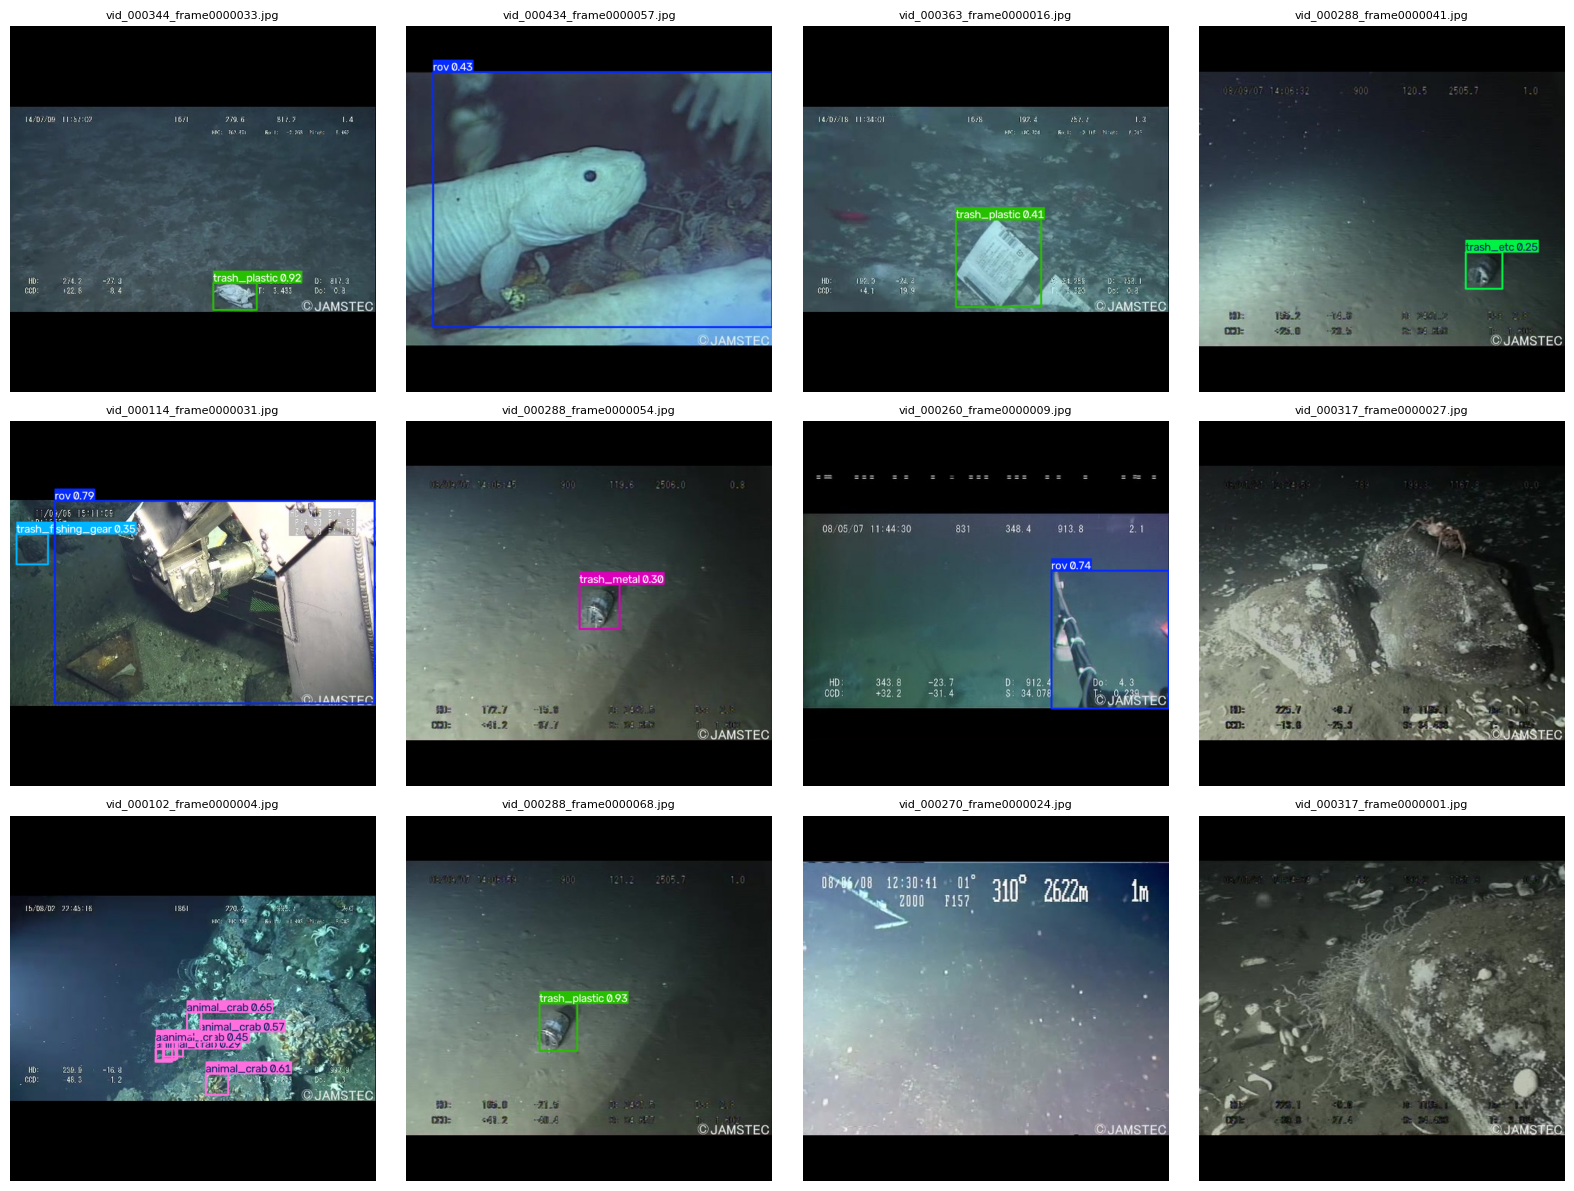

In [22]:
# Import required libraries
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Get all test images
test_images=list(TEST_DIR.glob("*.jpg"))

# Select 12 random test images for qualitative analysis
random.seed(42)
sample_images=random.sample(test_images,12)

# Run YOLO prediction only on these 12 images
prediction_results=best_model.predict(
    source=[str(img) for img in sample_images],
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

# Display the 12 prediction results
fig,axes=plt.subplots(3,4,figsize=(16,12))

for ax,result,img_path in zip(axes.ravel(),prediction_results,sample_images):
    # Convert YOLO result to an RGB image
    plotted=result.plot()
    plotted=plotted[:,:,::-1]

    # Display the prediction
    ax.imshow(plotted)
    ax.set_title(Path(img_path).name,fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()